1. Setup

In [1]:
# =========================================================
# Librerías base
# =========================================================
import os
import sys
import importlib
import time
import joblib

# Manejo de datos
import pandas as pd
import numpy as np

# Preprocesamiento
from sklearn.preprocessing import StandardScaler

# Métricas
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

# Pesos de clase
from sklearn.utils.class_weight import compute_class_weight

# TensorFlow / Keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# Detecta la raíz del proyecto
# ---------------------------------------------------------
PROJECT_ROOT = os.path.abspath("..")

# ---------------------------------------------------------
# Agrega la raíz del proyecto al path para importar config
# ---------------------------------------------------------
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

# ---------------------------------------------------------
# Importa configuración del proyecto
# ---------------------------------------------------------
import utils.config as config
importlib.reload(config)

print("FULL_ARTIFACTS_DIR:", config.FULL_ARTIFACTS_DIR)

I0000 00:00:1777834815.525386   14998 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777834818.414453   14998 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777834824.769690   14998 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


FULL_ARTIFACTS_DIR: /home/bryan_santanderaragon/Proyecto_MBD/data/artifacts/full


2. Cargar artefactos multiclase full

In [2]:
# ---------------------------------------------------------
# Carga datasets multiclase full
# ---------------------------------------------------------
X_train_multi = pd.read_parquet(
    os.path.join(config.FULL_ARTIFACTS_DIR, "X_train_full_multiclass.parquet")
)

X_test_multi = pd.read_parquet(
    os.path.join(config.FULL_ARTIFACTS_DIR, "X_test_full_multiclass.parquet")
)

y_train_multi = pd.read_csv(
    os.path.join(config.FULL_ARTIFACTS_DIR, "y_train_full_multiclass.csv")
).squeeze("columns")

y_test_multi = pd.read_csv(
    os.path.join(config.FULL_ARTIFACTS_DIR, "y_test_full_multiclass.csv")
).squeeze("columns")

print("X_train_multi:", X_train_multi.shape)
print("X_test_multi:", X_test_multi.shape)

X_train_multi: (17871216, 22)
X_test_multi: (4467805, 22)


3. Revisar distribución de clases

In [3]:
# ---------------------------------------------------------
# Muestra la distribución de clases del target multiclase
# para confirmar el desbalance
# ---------------------------------------------------------
class_distribution = pd.Series(y_train_multi).value_counts().sort_index()

print("Distribución de clases en y_train:")
print(class_distribution)

Distribución de clases en y_train:
type
backdoor       406493
ddos          4932006
dos           2700262
injection      362127
mitm              842
normal         637104
password      1374854
ransomware      58244
scanning      5712129
xss           1687155
Name: count, dtype: int64


4. Escalar variables

In [4]:
# ---------------------------------------------------------
# Crea un escalador estándar
# ---------------------------------------------------------
scaler = StandardScaler()

# ---------------------------------------------------------
# Ajusta el scaler con train y transforma train/test
# ---------------------------------------------------------
X_train_scaled = scaler.fit_transform(X_train_multi)
X_test_scaled = scaler.transform(X_test_multi)

print("Escalado completado.")
print("Shape train escalado:", X_train_scaled.shape)
print("Shape test escalado:", X_test_scaled.shape)

Escalado completado.
Shape train escalado: (17871216, 22)
Shape test escalado: (4467805, 22)


Liberar memoria

In [5]:
import gc

del X_train_multi
del X_test_multi
gc.collect()

print("Memoria liberada de X_train y X_test")

Memoria liberada de X_train y X_test


5. Preparar target multiclase

In [6]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
import joblib
import os

# ---------------------------------------------------------
# Codificar target multiclase a enteros
# ---------------------------------------------------------
target_encoder_multi = LabelEncoder()

y_train_multi_enc = target_encoder_multi.fit_transform(y_train_multi.astype(str))
y_test_multi_enc = target_encoder_multi.transform(y_test_multi.astype(str))

# ---------------------------------------------------------
# Guardar encoder para reutilizarlo después
# ---------------------------------------------------------
joblib.dump(
    target_encoder_multi,
    os.path.join(config.FULL_ARTIFACTS_DIR, "target_encoder_full_multiclass.pkl")
)

# ---------------------------------------------------------
# Número de clases
# ---------------------------------------------------------
num_classes = len(target_encoder_multi.classes_)
print("Número de clases:", num_classes)
print("Clases:", list(target_encoder_multi.classes_))

# ---------------------------------------------------------
# One-hot encoding para softmax
# ---------------------------------------------------------
y_train_cat = to_categorical(y_train_multi_enc, num_classes=num_classes)
y_test_cat = to_categorical(y_test_multi_enc, num_classes=num_classes)

print("Shape y_train_cat:", y_train_cat.shape)
print("Shape y_test_cat:", y_test_cat.shape)

Número de clases: 10
Clases: ['backdoor', 'ddos', 'dos', 'injection', 'mitm', 'normal', 'password', 'ransomware', 'scanning', 'xss']
Shape y_train_cat: (17871216, 10)
Shape y_test_cat: (4467805, 10)


6. Calcular pesos de clase

In [7]:
# ---------------------------------------------------------
# Calcula pesos de clase balanceados automáticamente
# ---------------------------------------------------------
classes = np.unique(y_train_multi)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_multi
)

class_weights = dict(zip(classes, weights))

print("Pesos de clase:")
print(class_weights)

Pesos de clase:
{'backdoor': np.float64(4.396438807064328), 'ddos': np.float64(0.36235187061816226), 'dos': np.float64(0.661832666607907), 'injection': np.float64(4.935068636141464), 'mitm': np.float64(2122.4722090261284), 'normal': np.float64(2.805070443758005), 'password': np.float64(1.2998628217978054), 'ransomware': np.float64(30.683359659364054), 'scanning': np.float64(0.3128643628321419), 'xss': np.float64(1.0592515803230882)}


7. Construir el modelo DNN multiclase

In [8]:
# ---------------------------------------------------------
# Define una red neuronal densa (feedforward)
# para clasificación multiclase
# ---------------------------------------------------------
dnn_model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),

    Dense(128, activation="relu"),
    Dropout(0.3),

    Dense(64, activation="relu"),
    Dropout(0.3),

    Dense(32, activation="relu"),

    Dense(num_classes, activation="softmax")
])

# ---------------------------------------------------------
# Compila el modelo
# categorical_crossentropy porque es multiclase
# ---------------------------------------------------------
dnn_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

dnn_model.summary()

E0000 00:00:1777834933.690091   14998 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,610 (53.16 KB)

 Trainable params: 13,610 (53.16 KB)

 Non-trainable params: 0 (0.00 B)

8. Configurar EarlyStopping

In [9]:
# ---------------------------------------------------------
# EarlyStopping detiene el entrenamiento si la validación
# deja de mejorar durante varias épocas
# ---------------------------------------------------------
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

9. Entrenar el DNN multiclase

In [10]:
# ---------------------------------------------------------
# Entrena la red neuronal
# validation_split=0.2 separa parte de train para validación
# batch_size controla cuántas muestras ve por iteración
# class_weight ayuda con el desbalance
# ---------------------------------------------------------
train_start = time.time()

history = dnn_model.fit(
    X_train_scaled,
    y_train_cat,
    validation_split=0.2,
    epochs=20,
    batch_size=256,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

train_elapsed = time.time() - train_start
print(f"✔ DNN multiclase entrenado en {train_elapsed:.2f} seg")

Epoch 1/20
55848/55848 ━━━━━━━━━━━━━━━━━━━━ 324s 6ms/step - accuracy: 0.8159 - loss: 0.5097 - val_accuracy: 0.8429 - val_loss: 0.4325
Epoch 2/20
55848/55848 ━━━━━━━━━━━━━━━━━━━━ 349s 6ms/step - accuracy: 0.8322 - loss: 0.4610 - val_accuracy: 0.8436 - val_loss: 0.4229
Epoch 3/20
55848/55848 ━━━━━━━━━━━━━━━━━━━━ 304s 5ms/step - accuracy: 0.8350 - loss: 0.4594 - val_accuracy: 0.8490 - val_loss: 0.4144
Epoch 4/20
55848/55848 ━━━━━━━━━━━━━━━━━━━━ 309s 6ms/step - accuracy: 0.8373 - loss: 0.4865 - val_accuracy: 0.8502 - val_loss: 0.4065
Epoch 5/20
55848/55848 ━━━━━━━━━━━━━━━━━━━━ 317s 6ms/step - accuracy: 0.8396 - loss: 0.4411 - val_accuracy: 0.8484 - val_loss: 0.4071
Epoch 6/20
55848/55848 ━━━━━━━━━━━━━━━━━━━━ 300s 5ms/step - accuracy: 0.8415 - loss: 0.4365 - val_accuracy: 0.8379 - val_loss: 0.4293
Epoch 7/20
55848/55848 ━━━━━━━━━━━━━━━━━━━━ 300s 5ms/step - accuracy: 0.8426 - loss: 0.4356 - val_accuracy: 0.8532 - val_loss: 0.4013
Epoch 8/20
55848/55848 ━━━━━━━━━━━━━━━━━━━━ 308s 5ms/step - ac

10. Evaluar el modelo

In [11]:
import numpy as np
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# ---------------------------------------------------------
# 1. Codificar etiquetas multiclase
# ---------------------------------------------------------
label_encoder = LabelEncoder()

y_train_enc = label_encoder.fit_transform(y_train_multi)
y_test_enc = label_encoder.transform(y_test_multi)

num_classes = len(label_encoder.classes_)

print("Clases:", label_encoder.classes_)
print("Número de clases:", num_classes)

# ---------------------------------------------------------
# 2. Convertir a one-hot para la DNN
# ---------------------------------------------------------
y_train_cat = to_categorical(y_train_enc, num_classes=num_classes)
y_test_cat = to_categorical(y_test_enc, num_classes=num_classes)

Clases: ['backdoor' 'ddos' 'dos' 'injection' 'mitm' 'normal' 'password'
 'ransomware' 'scanning' 'xss']
Número de clases: 10


In [12]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

# Predicción
y_pred_prob = dnn_model.predict(X_test_scaled)
y_pred_eval = np.argmax(y_pred_prob, axis=1)

# Verdaderos
y_test_eval = y_test_enc

# Métricas
acc = accuracy_score(y_test_eval, y_pred_eval)

precision_w, recall_w, f1_w, _ = precision_recall_fscore_support(
    y_test_eval,
    y_pred_eval,
    average="weighted",
    zero_division=0
)

precision_m, recall_m, f1_m, _ = precision_recall_fscore_support(
    y_test_eval,
    y_pred_eval,
    average="macro",
    zero_division=0
)

print("Accuracy:", acc)
print("F1 weighted:", f1_w)
print("F1 macro:", f1_m)

print("\nReporte completo:")
print(classification_report(
    y_test_eval,
    y_pred_eval,
    target_names=label_encoder.classes_,
    zero_division=0
))

139619/139619 ━━━━━━━━━━━━━━━━━━━━ 200s 1ms/step
Accuracy: 0.8580363288012793
F1 weighted: 0.8554298593345221
F1 macro: 0.6583065300934148

Reporte completo:
              precision    recall  f1-score   support

    backdoor       0.00      0.00      0.00    101623
        ddos       0.99      0.95      0.97   1233002
         dos       0.57      0.99      0.72    675066
   injection       0.90      0.81      0.85     90532
        mitm       0.00      0.00      0.00       210
      normal       0.92      0.80      0.86    159276
    password       0.96      0.88      0.92    343714
  ransomware       0.59      0.39      0.47     14561
    scanning       0.94      0.76      0.84   1428032
         xss       0.93      0.97      0.95    421789

    accuracy                           0.86   4467805
   macro avg       0.68      0.65      0.66   4467805
weighted avg       0.88      0.86      0.86   4467805



11. Curvas de entrenamiento

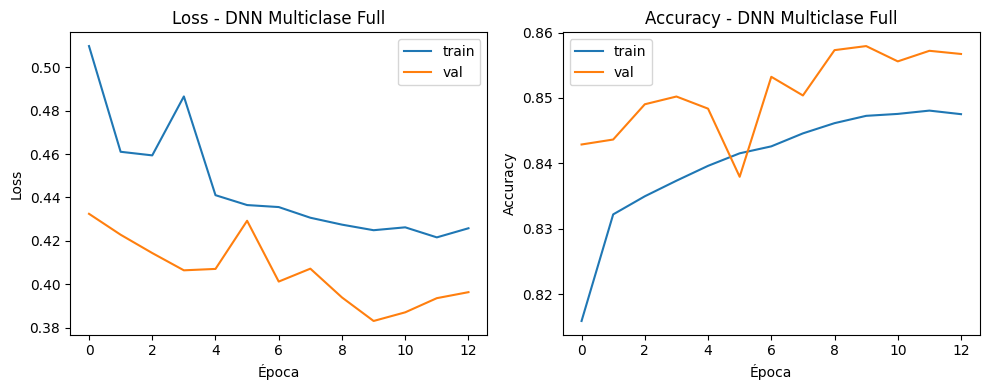

In [13]:
# ---------------------------------------------------------
# Grafica pérdida y accuracy durante el entrenamiento
# ---------------------------------------------------------
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss - DNN Multiclase Full")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.title("Accuracy - DNN Multiclase Full")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

12. Matriz de confusión multiclase

In [14]:
# ---------------------------------------------------------
# Reconstruye los nombres de clases desde el dataset full
# para mostrar los nombres reales en la matriz
# ---------------------------------------------------------
from sklearn.preprocessing import LabelEncoder

df_full = pd.read_parquet(config.FULL_CONSOLIDATED_PATH)

target_encoder = LabelEncoder()
target_encoder.fit(df_full[config.MULTICLASS_TARGET].astype(str))

class_names = list(target_encoder.classes_)
print("Clases:", class_names)

Clases: ['backdoor', 'ddos', 'dos', 'injection', 'mitm', 'normal', 'password', 'ransomware', 'scanning', 'xss']


Función para graficar matriz de confusión

In [15]:
# ---------------------------------------------------------
# Función para graficar matriz de confusión
# ---------------------------------------------------------
def plot_confusion(y_true, y_pred, title, class_names, figsize=(12, 9), annot=False):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=figsize)
    sns.heatmap(
        cm,
        annot=annot,
        fmt="d" if annot else "",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title(title)
    plt.xlabel("Predicción")
    plt.ylabel("Valor real")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.show()

Grafico de matriz de confusión

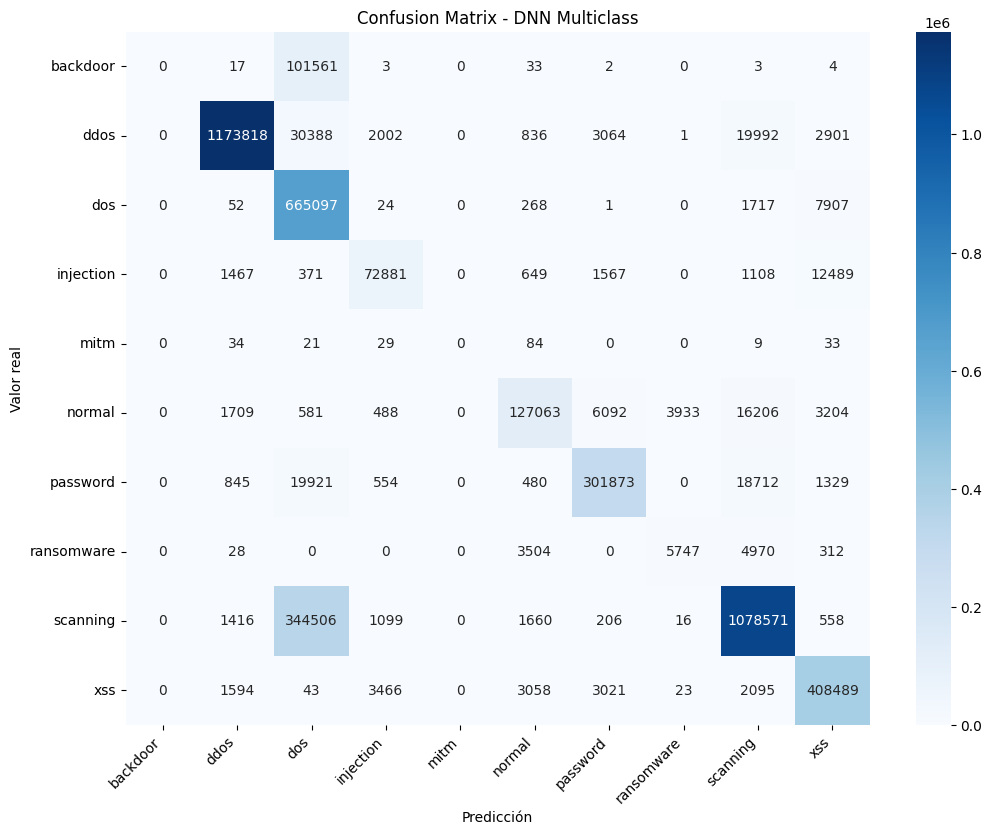

In [16]:
plot_confusion(
    y_test_eval,
    y_pred_eval,
    "Confusion Matrix - DNN Multiclass",
    label_encoder.classes_,
    figsize=(12, 9),
    annot=True
)

Guardar modelo

In [17]:
# ---------------------------------------------------------
# Guarda el modelo DNN y el scaler
# ---------------------------------------------------------
dnn_model.save(
    os.path.join(config.FULL_ARTIFACTS_DIR, "dnn_multiclass_full.keras")
)

joblib.dump(
    scaler,
    os.path.join(config.FULL_ARTIFACTS_DIR, "scaler_multiclass_full.pkl")
)

print("Modelo y scaler guardados correctamente.")

Modelo y scaler guardados correctamente.


Guardar metricas y predicciones

In [18]:
dnn_results = {
    "model": "DNN Full Multiclass",
    "accuracy": acc,
    "precision_weighted": precision_w,
    "recall_weighted": recall_w,
    "f1_weighted": f1_w,
    "precision_macro": precision_m,
    "recall_macro": recall_m,
    "f1_macro": f1_m
}
# ---------------------------------------------------------
# Guarda resultados del modelo
# ---------------------------------------------------------
pd.DataFrame([dnn_results]).to_csv(
    os.path.join(config.FULL_ARTIFACTS_DIR, "dnn_multiclass_results_full.csv"),
    index=False
)

# ---------------------------------------------------------
# Guarda predicciones para análisis posterior
# ---------------------------------------------------------
pd.DataFrame({
    "y_true": y_test_eval,
    "y_pred": y_pred_eval
}).to_csv(
    os.path.join(config.FULL_ARTIFACTS_DIR, "dnn_multiclass_predictions_full.csv"),
    index=False
)

print("Resultados y predicciones guardados.")

Resultados y predicciones guardados.
